# LAI analysis

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime as dt
import tarfile
import sys
import glob
import scipy.stats as stats
import zipfile
import shutil
import matplotlib as mpl
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.dates as mdates
#from utils import *

#sys.path.insert(1, '../')
from swaplib import *

data_dir = "/media/geoecology-arbeitsgruppen/Hydrologie/maik/gwr-bb-cc/data/"#set_data_dir()

# Sandbox

In [4]:
def read_lai_file(f):
    ro = rio.open(f)
    data = ro.read(1)
    data = data.astype("f4")
    data[data==65535.] = np.nan
    data *= 0.001
    return data

In [5]:
files = glob.glob("/media/x/cosmicsense/data/lai/*/*.tif", recursive=True)

In [6]:
ro = rio.open(files[500])

In [7]:
data = ro.read(1)
data = data.astype("f4")
data[data==65535.] = np.nan
data *= 0.001

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


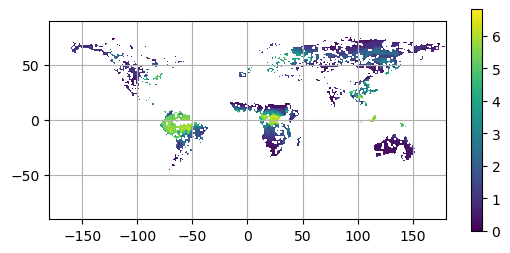

In [8]:
cp = plt.imshow(data, extent=[-180, 180, -90, 90])
plt.colorbar(cp, shrink=0.6)
plt.grid()

In [11]:
nlats = ro.shape[0]
nlons = ro.shape[1]
lats = np.linspace(90, -90, nlats)
lons = np.linspace(-180, 180, nlons)

In [12]:
nlats, nlons

(2160, 4320)

In [13]:
bb = gpd.read_file("/media/geoecology-arbeitsgruppen/Hydrologie/maik/gwr-bb-cc/data/geo/berlin-bb_30km.shp")

In [16]:
ezgnames = ["Plane-Buckau", "Nuthe", "Obere Dahme", 
            "Stepenitz-Loecknitz", "Ucker-Welse", "Brandenburg"]
ezgs = {}
ezgbounds = {}
ezgixes = {}
for ezgname in ezgnames:
    if ezgname=="Brandenburg":
        ezgfile = "geo/berlin-bb.shp"
    else:
        ezgfile = "geo/ezg/%s.geojson" % ezgname
    fezg = os.path.join(data_dir, ezgfile)
    ezg = gpd.read_file(fezg).to_crs("epsg:4326")
    ezgs[ezgname] = ezg
    bbleft, bbbottom, bbright, bbtop = ezg.total_bounds
    ezgbounds[ezgname] = [bbleft, bbbottom, bbright, bbtop]
    lonmini, lonmaxi = np.where((lons>=bbleft) & (lons<=bbright))[0][[0,-1]]
    latmini, latmaxi = np.where((lats>=bbbottom) & (lats<=bbtop))[0][[0,-1]]
    ezgixes[ezgname] = lonmini, lonmaxi, latmini, latmaxi

In [17]:
# For all of Brandenburg
bbleft, bbbottom, bbright, bbtop = bb.total_bounds
bbleft, bbbottom, bbright, bbtop

(11.241871610839588, 51.315724675156886, 14.82173062750238, 53.58129007492342)

In [18]:
# For grasslands around Paulinenaue
#bbleft, bbbottom, bbright, bbtop = 12.693080840356108, 52.65, 12.79657325787964, 52.8

In [19]:
#bbleft, bbbottom, bbright, bbtop = 7, 47, 17, 57

In [20]:
np.where((lats>=bbbottom) & (lats<=bbtop))[0]

array([437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449,
       450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462,
       463])

In [21]:
lonmini, lonmaxi = np.where((lons>=bbleft) & (lons<=bbright))[0][[0,-1]]
latmini, latmaxi = np.where((lats>=bbbottom) & (lats<=bbtop))[0][[0,-1]]

In [22]:
#np.all(np.isnan(data[latmini:latmaxi, lonmini:lonmaxi]))

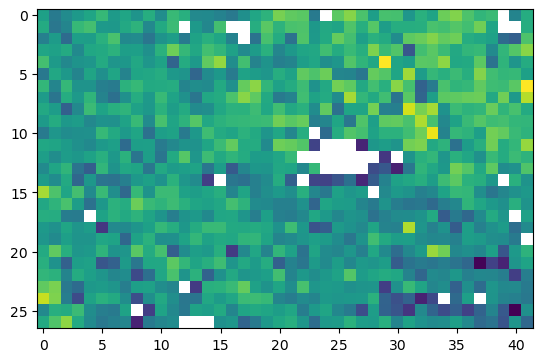

In [23]:
plt.imshow(data[latmini:latmaxi+1, lonmini:lonmaxi])

In [38]:
read_anew = False

if read_anew:
    dtimes = []
    #alldata = np.zeros( (len(files), ro.shape[0], ro.shape[1]) )
    
    for file in files:
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        dtimes.append(dtime)
    
    df = pd.DataFrame(index=dtimes, columns=ezgnames)
    df = df.sort_index()
    
    for file in files:
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        data = read_lai_file(file)
        for ezgname in ezgnames:
            lonmini, lonmaxi, latmini, latmaxi = ezgixes[ezgname]
            avg = np.nanmean(data[latmini:latmaxi, lonmini:lonmaxi])
            df.loc[[dtime],[ezgname]] = [avg]
        # tmp = rio.open(file)
        # data = tmp.read(1)
        # data = data.astype("f4")
        # data[data==65535.] = np.nan
        # data *= 0.001
        #avgs.append(np.nanmean(data[latmini:latmaxi, lonmini:lonmaxi]))
    df.to_csv(os.path.join(data_dir, "series4trends/lai.csv"), index=True, index_label="datetime")
else:
    df = pd.read_csv(os.path.join(data_dir, "series4trends/lai.csv"), parse_dates=True, index_col="datetime")

In [39]:
# data = pd.DataFrame({"dtimes":dtimes, "lai":avgs})
# data = data.set_index("dtimes")
# data = data.sort_index()

In [25]:
def get_linear_trend(df, var, start, end, verbose=True):
    tmptrend = df.loc[start:end]
    tmptrend.loc[tmptrend.index,["delta"]] = [(item - tmptrend.index[0]).total_seconds() for item in tmptrend.index]
    slope, intercept, r, p, se = scipy.stats.linregress(tmptrend.delta.to_numpy(), tmptrend[var].to_numpy())
    ypred = intercept + slope*tmptrend.delta
    pstr = get_sign_level(p)
    slope *= 365.25*86400*10
    se *= 365.25*86400*10
    if verbose:
        print("slope=%.2f%s +/- %.2f, p=%.2f" % (slope, pstr, se, p))
    return slope, intercept, r, p, se, ypred, pstr

In [41]:
for ezgname in ezgnames:
    print(ezgname)
    slope, intercept, r, p, se, ypred, pstr = get_linear_trend(df, ezgname, "1981-01-01", "2020-12-31")

Plane-Buckau
slope=0.09*** +/- 0.02, p=0.00
Nuthe
slope=0.07*** +/- 0.02, p=0.00
Obere Dahme
slope=0.12*** +/- 0.02, p=0.00
Stepenitz-Loecknitz
slope=0.06** +/- 0.02, p=0.01
Ucker-Welse
slope=0.06** +/- 0.02, p=0.01
Brandenburg
slope=0.08*** +/- 0.02, p=0.00


In [42]:
# plt.subplots(1,1)
# plt.plot(data.index, data.lai, color="black")
# plt.plot(data.index, ypred, color="tab:red", ls="--", lw=2)
# plt.ylabel("LAI (m2/m2)")
# plt.grid()
# plt.xlim(dt.datetime(1982,1,1), dt.datetime(2020,12,31))
# t = plt.text(dt.datetime(1984,1,1), 0.3, r"%.2f$\pm$%.2fm²/m²/dec%s" % (slope, se, pstr), 
#              color="tab:red", ha="left", fontsize=12)
# t.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none'))

NameError: name 't' is not defined

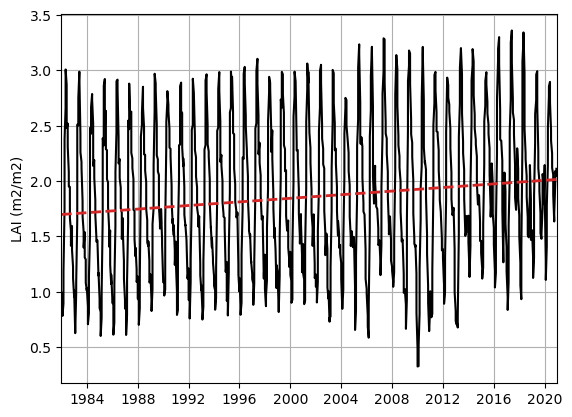

In [43]:
plt.subplots(1,1)
plt.plot(df.index, df.Brandenburg, color="black")
plt.plot(df.index, ypred, color="tab:red", ls="--", lw=2)
plt.ylabel("LAI (m2/m2)")
plt.grid()
plt.xlim(dt.datetime(1982,1,1), dt.datetime(2020,12,31))
# t = plt.text(dt.datetime(1984,1,1), 0.3, r"%.2f$\pm$%.2fm²/m²/dec%s" % (slope, se, pstr), 
#              color="tab:red", ha="left", fontsize=12)
t.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.xlim(dt.datetime(2008,1,1), dt.datetime(2014,1,1))

# Masking with polygons instead of bboxes

In [9]:
import rasterio.mask as riom
import warnings

In [10]:
bb = gpd.read_file(data_dir+"/geo/bb.geojson").to_crs("epsg:25833")

In [11]:
xmin, ymin, xmax, ymax = bb.total_bounds

In [12]:
# CORINE
corine = gpd.read_file("/media/x/cosmicsense/data/brandenburg/corine/U2018_CLC2018_V2020_20u1.shp/U2018_CLC2018_V2020_20u1.shp").to_crs("epsg:25833")
corine = corine.drop(columns=['OBJECTID', 'Remark', 'Area_Ha', 'ID', 'Shape_Leng',
       'Shape_Area'])
corine["Code_18"] = corine.Code_18.astype(int)
ccodes = {"pineforest":[312],
          "grassland": [231, 321, 322],
          "broadleavedforest": [311, 313],
          "cropland": [211, 212, 213, 221, 222, 241, 242, 243]}

In [13]:
caovgrid = gpd.read_file("/media/x/cosmicsense/data/brandenburg/vast-landuse/cao-vector-grid.shp").to_crs("epsg:25833")
caovgrid = caovgrid.drop(index = caovgrid[caovgrid.VALUE==65535.].index)
caovgrid["cid"] = caovgrid.index
caovgrid = caovgrid.drop(columns=["VALUE"])

In [14]:
isc = caovgrid.overlay(corine, how="intersection")
isc["area"] = isc.area

In [15]:
isc["code"] = 0
isc.loc[np.in1d(isc.Code_18, ccodes["cropland"]), ["code"]] = 1
iscgb = isc[["cid","code", "area"]].groupby(["cid","code"]).sum()
iscgb.xs(key=1, level=1)

,area
cid,
2324,1.135228e+07
2325,3.343349e+06
2398,5.887298e+06
2399,3.150800e+07
2400,3.657519e+07
...,...
4299,1.919180e+07
4300,6.217327e+06
4301,5.807131e+06


<Axes: >

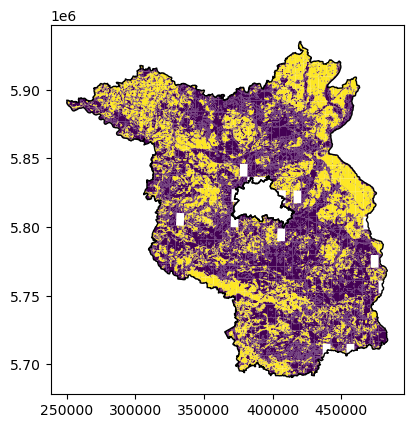

In [16]:
ax = isc.plot(column="code", edgecolor="None")
bb.plot(ax=ax, facecolor="None")


In [17]:
def get_fraction_in_cao(landuse):
    isc["code"] = 0
    isc.loc[np.in1d(isc.Code_18, ccodes[landuse]), ["code"]] = 1
    iscgb = isc[["cid","code", "area"]].groupby(["cid","code"]).sum()
    area = iscgb.xs(key=1, level=1)
    area.index = area.index.astype("int")
    caovgrid["area_%s" % landuse] = 0.
    
    caovgrid.loc[area.index, "area_%s" % landuse] = area.area
    
    caovgrid["frac_%s" % landuse] = caovgrid["area_%s" % landuse]/caovgrid.area

for landuse in ccodes.keys():
    get_fraction_in_cao(landuse)

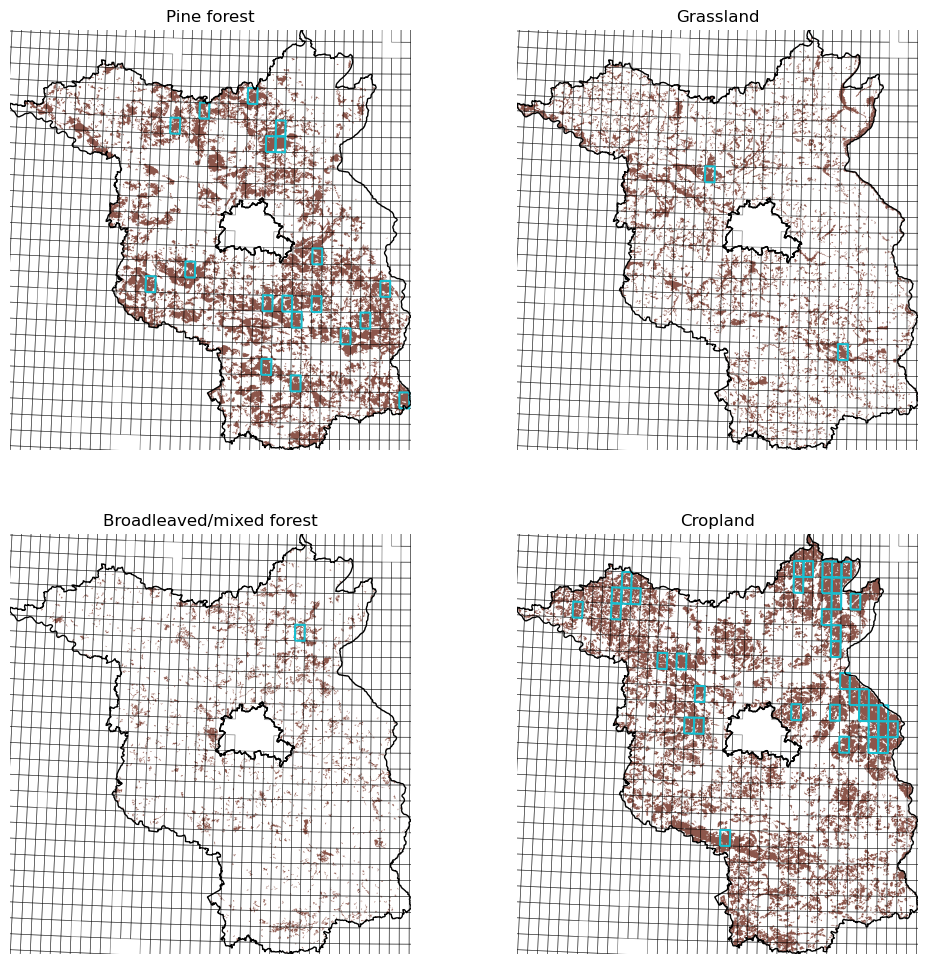

In [18]:
titles = {"pineforest":"Pine forest",
          "grassland": "Grassland",
          "broadleavedforest": "Broadleaved/mixed forest",
          "cropland": "Cropland"}
def decorate(ax, selection, landuse):
    plt.sca(ax)
    colors = np.repeat("None", len(corine)).astype('<U20')
    colors[np.in1d(corine.Code_18, ccodes[landuse])] = "tab:brown"
    corine.plot(ax=ax, color=colors, edgecolor="None")
    
    caovgrid.plot(ax=ax, facecolor="None", edgecolor="black", linewidth=0.5, alpha=0.5)
    selection.plot(ax=ax, edgecolor="tab:cyan", facecolor="None", linewidth=1.5)
    bb.plot(ax=ax, edgecolor="black", facecolor="None")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.title(titles[landuse])
    plt.axis("off")

fig, ax = plt.subplots(2,2, figsize=(12,12))
ax = ax.ravel()

threshs = {"pineforest":0.75,
          "grassland": 0.7,
          "broadleavedforest": 0.4,
          "cropland": 0.75}
caomask = {}
for i, landuse in enumerate( ccodes.keys()):
    caomask[landuse] = caovgrid.loc[caovgrid["frac_%s" % landuse]>=threshs[landuse]]
    decorate(ax[i], caomask[landuse], landuse)

plt.savefig("../figs/cao_cells.png", dpi=300)

In [19]:
ro.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [20]:
masks = {}
ro = rio.open(files[500])
for landuse in ccodes.keys():
    mask, transform = riom.mask(ro, [geom for geom in caomask[landuse].dissolve().to_crs(ro.crs).geometry])
    masks[landuse] = mask.astype("bool")[0]

/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/rasterio/mask.py:191: RuntimeWarning: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
  out_image = dataset.read(


In [21]:
# fig, ax = plt.subplots(1,1)
# plt.imshow(masks["pineforest"], extent=(-180, 180, -90, 90), cmap=plt.cm.Greens)
# caomask["pineforest"].to_crs(ro.crs).plot(ax=ax, facecolor="None", edgecolor="red")
# bb.plot(ax=ax, facecolor="None", edgecolor="black")
# plt.xlim(11,15)
# plt.ylim(51.5,53.5)

In [22]:
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message="TIFFReadDirectory:Sum of Photometric.*"
)

In [24]:
read_anew = True
results = {}

if read_anew:
    dtimes = []
    #alldata = np.zeros( (len(files), ro.shape[0], ro.shape[1]) )
    
    for file in files:
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        dtimes.append(dtime)
    
    df = pd.DataFrame(index=dtimes, columns=list(ccodes.keys()))
    dfmax = pd.DataFrame(index=dtimes, columns=list(ccodes.keys()))
    dfmin = pd.DataFrame(index=dtimes, columns=list(ccodes.keys()))
    df = df.sort_index()
    dfmax = dfmax.sort_index()
    dfmin = dfmin.sort_index()   

    warnings.filterwarnings("ignore", category=UserWarning)
    for file in files:
        print(".", end="")
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        data = read_lai_file(file)
        for key in list(masks.keys()):
            tmp = data[masks[key]].ravel()
            tmp = tmp[~np.isnan(tmp)]
            avg = np.mean(tmp)
            df.loc[[dtime],[key]] = [avg]
            mini, maxi = np.quantile(tmp, [0.25, 0.75])
            dfmax.loc[[dtime],[key]] = [maxi]
            dfmin.loc[[dtime],[key]] = [mini]
        # tmp = rio.open(file)
        # data = tmp.read(1)
        # data = data.astype("f4")
        # data[data==65535.] = np.nan
        # data *= 0.001
        #avgs.append(np.nanmean(data[latmini:latmaxi, lonmini:lonmaxi]))
    print("")
    warnings.filterwarnings("default", category=UserWarning)
    #df.to_csv(os.path.join(data_dir, "series4trends/lai.csv"), index=True, index_label="datetime")
else:
    pass
    #df = pd.read_csv(os.path.join(data_dir, "series4trends/lai.csv"), parse_dates=True, index_col="datetime")

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................


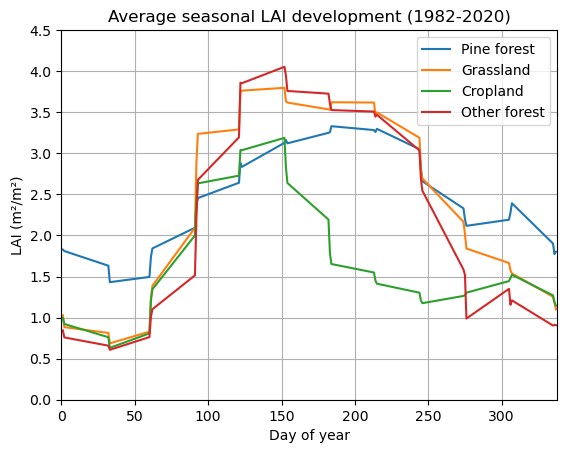

In [25]:
fig, ax = plt.subplots(1,1)
tmp = df.groupby(df.index.dayofyear).mean()
plt.plot(tmp.index, tmp["pineforest"], label="Pine forest")
plt.plot(tmp.index, tmp["grassland"], label="Grassland")
plt.plot(tmp.index, tmp["cropland"], label="Cropland")
plt.plot(tmp.index, tmp["broadleavedforest"], label="Other forest")
# tmp = dfmax.groupby(dfmax.index.dayofyear).mean()
# plt.plot(2*tmp.index/365, tmp, label="75. Perzentil")
# tmp = dfmin.groupby(dfmax.index.dayofyear).mean()
# plt.plot(2*tmp.index/365, tmp, label="25. Perzentil")
# Previous seasonal LAI for grass
#plt.plot([0, 0.5, 1, 1.5, 2], [0.5, 2., 3., 2., 0.5])
#plt.plot([0, 0.25, 0.5, 0.85, 1., 1.15, 1.5, 1.75, 2], [1.25, 1.25, 1.5, 2.75, 3., 2.75, 1.5, 1.35, 1.35])
plt.xlabel("Day of year")
plt.legend()
plt.xlim(0,338)
plt.ylim(0,4.5)
plt.ylabel("LAI (m²/m²)")
plt.grid()
plt.title("Average seasonal LAI development (1982-2020)")
plt.savefig("../figs/mean_seasonal_LAI.pdf")

In [26]:
caovgrid["fracsum"] = caovgrid[["frac_pineforest", "frac_grassland", "frac_cropland", "frac_broadleavedforest"]].sum(axis=1)

(5690476.478942125, 5935094.438939898)

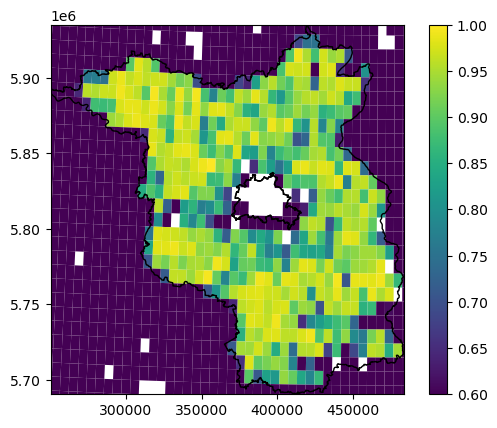

In [28]:
ax = caovgrid.plot(column="fracsum", legend=True, vmin=0.6)
bb.plot(ax=ax, facecolor="None")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

In [29]:
caovgridbb = caovgrid.overlay(bb, how="intersection")
caovgridbb = caovgridbb[caovgridbb.area>np.quantile(caovgridbb.area,0.2)]

(5690476.478942125, 5935094.438939898)

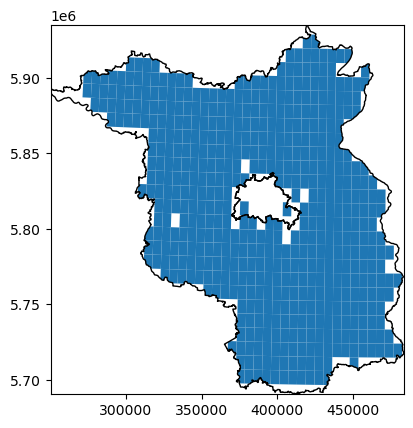

In [30]:
ax = caovgridbb.plot()
bb.plot(ax=ax, facecolor="None")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

# Systematic unmixing

In [2]:
import rasterio.mask as riom
import warnings

In [3]:
# https://zenodo.org/records/8281930/files/Readme_for_GIMMS_LAI4g_Product_updated_0825.pdf?download=1
def read_lai_file(f):
    ro = rio.open(f)
    data = ro.read(1)
    data = data.astype("f4")
    data[data==65535.] = np.nan
    data *= 0.001
    return data

In [4]:
bb = gpd.read_file(data_dir+"/geo/bb.geojson").to_crs("epsg:25833")
bbcolumns = bb.columns.tolist()
bbcolumns.remove("NUTS")
bbcolumns.remove("GEN")
bbcolumns.remove("geometry")
bb = bb.drop(columns=bbcolumns)

In [5]:
xmin, ymin, xmax, ymax = bb.total_bounds

### Check CORINE for most important LUTs

In [60]:
tmp

,Code_12,geometry
0,211,"POLYGON ((368561.745 5720093.407, 368549.917 5..."
1,231,"MULTIPOLYGON (((369695.131 5720228.921, 369560..."
2,231,"POLYGON ((368287.128 5722061.935, 368307.064 5..."
3,231,"POLYGON ((367418.533 5722592.046, 367407.413 5..."
4,231,"POLYGON ((368370.916 5723434.806, 368343.052 5..."
...,...,...
11556,512,"POLYGON ((382583.66 5875932.403, 382551.829 58..."
11557,512,"POLYGON ((379884.898 5882565.796, 379917.604 5..."
11558,512,"POLYGON ((382348.173 5894716.823, 382408.274 5..."
11559,512,"POLYGON ((382679.945 5900368.902, 382694.262 5..."


In [7]:
# Corine LUT codes
corinecodes = pd.read_csv("/media/x/cosmicsense/data/brandenburg/corine/U2018_CLC2018_V2020_20u1_doc/Info/Legend/Vector/CLC_legend.csv", sep=";")
corinecodes = corinecodes.set_index("CLC_CODE")

In [61]:
# CORINE
clc = {}
frags = ["U2000", "U2006", "U2012", "U2018", "U2018"]
for i, year in enumerate([1990, 2000, 2006, 2012, 2018]):
    tmp = gpd.read_file("/media/x/cosmicsense/data/brandenburg/corine/%s_CLC%d_V2020_20u1.shp/%s_CLC%d_V2020_20u1.shp" % (frags[i], year, frags[i], year)).to_crs("epsg:25833")
    tmp = tmp.rename(columns={"remark":"Remark", "id":"ID", "code_90":"ccode", "code_00":"ccode",
                              "Code_06":"ccode", "Code_12":"ccode", "Code_18":"ccode"})
    tmp = tmp.drop(columns=['OBJECTID', 'Remark', 'Area_Ha', 'ID', 'Shape_Leng', 'Shape_Area'])
    tmp["ccode"] = tmp.ccode.astype(int)
    clc[year] = tmp

In [6]:
# # CORINE
# corine = gpd.read_file("/media/x/cosmicsense/data/brandenburg/corine/U2018_CLC2018_V2020_20u1.shp/U2018_CLC2018_V2020_20u1.shp").to_crs("epsg:25833")
# corine = corine.drop(columns=['OBJECTID', 'Remark', 'Area_Ha', 'ID', 'Shape_Leng',
#        'Shape_Area'])
# corine["Code_18"] = corine.Code_18.astype(int)

In [62]:
corinebb = {}
corinebbperc = {}
for i, year in enumerate([1990, 2000, 2006, 2012, 2018]):
    corinebb[year] = clc[year].overlay(bb, how="intersection")
    corinebb[year]["area"] = corinebb[year].area
    corinebbperc[year] = (100 * corinebb[year][["area","ccode"]].groupby("ccode").sum()/corinebb[year][["area"]].sum()).sort_values("area", ascending=False)
    corinebbperc[year].columns = ["perc"]
    corinebbperc[year]["cumperc"] = corinebbperc[year].cumsum()
    corinebbperc[year] = corinebbperc[year].join(corinecodes[["LABEL3"]])

In [8]:
# corinebb = corine.overlay(bb, how="intersection")
# corinebb["area"] = corinebb.area
# corinebbperc = (100 * corinebb[["area","Code_18"]].groupby("Code_18").sum()/corinebb[["area"]].sum()).sort_values("area", ascending=False)
# corinebbperc.columns = ["perc"]
# corinebbperc["cumperc"] = corinebbperc.cumsum()
# corinebbperc = corinebbperc.join(corinecodes[["LABEL3"]])

In [63]:
corinebbperc[2018][corinebbperc[2018].cumperc<=99.95]

,perc,cumperc,LABEL3
ccode,,,
211,36.940476,36.940476,Non-irrigated arable land
312,30.306168,67.246644,Coniferous forest
231,14.219495,81.466139,Pastures
112,4.762301,86.228439,Discontinuous urban fabric
311,4.647534,90.875973,Broad-leaved forest
512,1.981322,92.857295,Water bodies
313,1.945988,94.803283,Mixed forest
121,1.125354,95.928637,Industrial or commercial units
324,0.703151,96.631788,Transitional woodland-shrub


In [64]:
corinebbperc[1990][corinebbperc[1990].cumperc<=99.95]

,perc,cumperc,LABEL3
ccode,,,
211,42.779317,42.779317,Non-irrigated arable land
312,28.686855,71.466172,Coniferous forest
231,8.852927,80.319099,Pastures
112,4.343055,84.662153,Discontinuous urban fabric
311,3.797274,88.459427,Broad-leaved forest
313,2.353132,90.812559,Mixed forest
243,2.149662,92.962221,"Land principally occupied by agriculture, with..."
512,1.818286,94.780507,Water bodies
321,1.045056,95.825564,Natural grasslands


In [65]:
# these cover > 99.9 percent of Bbg.
ccodes = {"pineforest":[312],
          "grassland": [231, 321, 322, 411],
          "otherforest": [141, 311, 313, 324],
          "cropland": [211, 222, 243],
          "other" : [111, 112, 121, 122, 142, 124, # "builtup" 
                     511, 512, # water
                     131, 132, 331, 333] # bare
         }

### Import and preprocess grid from Cao

In [66]:
def ids_from_latlon(x, y, precision=2):
    xstr = np.char.replace((x * 10**precision).astype(int).astype("str"), "-", "W")
    ystr = np.char.replace((y * 10**precision).astype(int).astype("str"), "-", "S")
    return np.char.add(xstr, ystr)

In [67]:
caovgrid = gpd.read_file("/media/x/cosmicsense/data/brandenburg/vast-landuse/cao-vector-grid.shp").to_crs("epsg:25833")
caovgrid = caovgrid.drop(index = caovgrid[caovgrid.VALUE==65535.].index)
#caovgrid["cid"] = caovgrid.index
caovgrid = caovgrid.drop(columns=["VALUE"])
caovgrid["cid"] = ids_from_latlon(caovgrid.centroid.to_crs("epsg:4326").geometry.x.to_numpy(),
                                  caovgrid.centroid.to_crs("epsg:4326").geometry.y.to_numpy())

In [68]:
caovgridbb = caovgrid.overlay(bb, how="intersection")
#caovgridbb = caovgridbb[caovgridbb.area>np.quantile(caovgridbb.area,0.25)]

(5690476.478942125, 5935094.438939898)

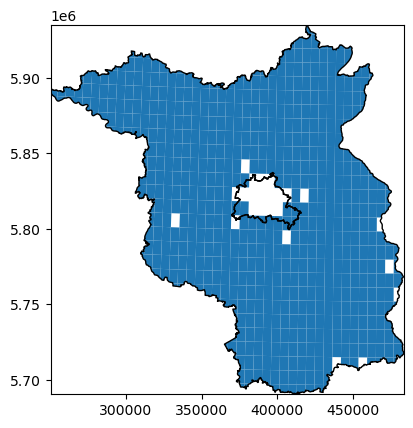

In [69]:
ax = caovgridbb.plot()
bb.plot(ax=ax, facecolor="None")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

In [70]:
isc = {}
for i, year in enumerate([1990, 2000, 2006, 2012, 2018]):
    isc[year] = caovgridbb.overlay(corinebb[year], how="intersection")
    isc[year]["area"] = isc[year].area

/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 181 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 171 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 170 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom

In [71]:
caovgridbb.to_file("../data/caovgridbb.geojson")

In [72]:
caovgridbb = caovgridbb.set_index("cid")

In [73]:
def get_fraction_in_cao(landuse, vgrid, year):
    vgrid = vgrid.copy()
    isc[year]["code"] = 0
    isc[year].loc[np.in1d(isc[year].ccode, ccodes[landuse]), ["code"]] = 1
    iscgb = isc[year][["cid","code", "area"]].groupby(["cid","code"]).sum()
    area = iscgb.xs(key=1, level=1)
    #area.index = area.index.astype("int")
    vgrid["area_%s_%d" % (landuse, year)] = 0.
    
    vgrid.loc[area.index, "area_%s_%d" % (landuse, year)] = area.area
    
    vgrid["frac_%s_%d" % (landuse, year)] = vgrid["area_%s_%d" % (landuse, year)]/vgrid.area

    return vgrid

In [75]:
for landuse in ccodes.keys():
    for i, year in enumerate([1990, 2000, 2006, 2012, 2018]): 
        caovgridbb = get_fraction_in_cao(landuse, caovgridbb, year)

In [76]:
caovgridbb = caovgridbb[caovgridbb.area>np.quantile(caovgridbb.area,0.25)]

### Read LAI data for remaining mask

In [77]:
files = glob.glob("/media/x/cosmicsense/data/lai/*/*.tif", recursive=True)

In [78]:
f = "/media/x/cosmicsense/data/lai/GIMMS_LAI4g_AVHRR_MODIS_consolidated_2001_2010/GIMMS_LAI4g_V1.2_20010101.tif"
tmprio = rio.open(f)
rows, cols = np.indices(tmprio.shape)
ix_pairs = np.column_stack((rows.ravel(), cols.ravel()))
lailons, lailats = tmprio.xy(ix_pairs[:,0],ix_pairs[:,1])
pixelids = ids_from_latlon(lailons, lailats)

In [79]:
fullgridmask = np.zeros(len(pixelids)).astype(bool)
for cid in caovgridbb.index:
    fullgridmask[np.where(pixelids==cid)[0][0]] = True

(52.0, 53.0)

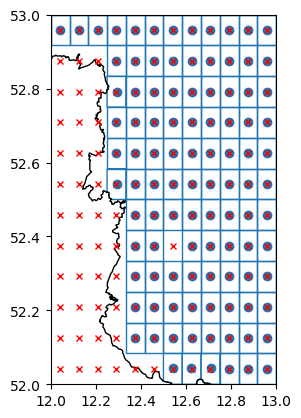

In [80]:
ax = caovgridbb.to_crs("epsg:4326").plot(facecolor="None", edgecolor="tab:blue")
ax.set_aspect("equal")
bb.to_crs("epsg:4326").plot(ax=ax, facecolor="None")
caovgridbb.centroid.to_crs("epsg:4326").plot(ax=ax)
plt.plot(lailons, lailats, "rx", ms=5)
plt.xlim(12,13)
plt.ylim(52, 53)


In [81]:
read_anew = False
results = {}

if read_anew:
    dtimes = []
    #alldata = np.zeros( (len(files), ro.shape[0], ro.shape[1]) )
    
    for file in files:
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        if dtime.day==2:
            # https://zenodo.org/records/8281930/files/Readme_for_GIMMS_LAI4g_Product_updated_0825.pdf?download=1
            # 1 refers to first half of month, 2 to second
            dtime = dt.datetime(dtime.year, dtime.month, 15)
        dtimes.append(dtime)
    
    df = pd.DataFrame(index=dtimes, columns=caovgridbb.index.tolist() )
    df = df.sort_index()

    warnings.filterwarnings("ignore", category=UserWarning)
    #warnings.filterwarnings("ignore", category=RuntimeWarning)
    for file in files:
        print(".", end="")
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        if dtime.day==2:
            # https://zenodo.org/records/8281930/files/Readme_for_GIMMS_LAI4g_Product_updated_0825.pdf?download=1
            # 1 refers to first half of month, 2 to second
            dtime = dt.datetime(dtime.year, dtime.month, 15)
        df.loc[dtime,:] = read_lai_file(file).ravel()[fullgridmask]
    print("")
    warnings.filterwarnings("default", category=UserWarning)
    #warnings.filterwarnings("default", category=RuntimeWarning)
    # fix datetime
    df = df.set_index(df.index)
    df.astype(float).to_csv("../data/lai-extract-from-cao.csv", sep=";", index=True, index_label="datetime", float_format="%.3f")
else:
    df = pd.read_csv("../data/lai-extract-from-cao.csv", sep=";", parse_dates=True, index_col="datetime")

### Unmixing

In [82]:
from scipy.optimize import minimize

In [83]:
def unmix(lais, fractions, laiobs):
    return np.sqrt(np.nanmean(((lais * fractions).sum(axis=1) - laiobs)**2))

In [89]:
def interpol(year1, year2, lut):
    tmp = np.zeros(len(caovgridbb))*np.nan
    for i, cid in enumerate(caovgridbb.index):
        tmp[i] = np.interp(year, [year1, year2], 
                  [caovgridbb.at[cid, "frac_%s_%d" % (lut, year1)], 
                   caovgridbb.at[cid, "frac_%s_%d" % (lut, year2)]])
    return tmp

    
def get_fractions_in_year(lut, year):
    years = [1990, 2000, 2006, 2012, 2018]
    if year <= 1990:
        # extrapolate: nearest neighbour
        return caovgridbb["frac_%s_1990" % lut].to_numpy()
    elif year >= 2018:
        # extrapolate: nearest neighbour
        return caovgridbb["frac_%s_2018" % lut].to_numpy()
    elif (year > 1990) and (year <= 2000):
        return interpol(1990, 2000, lut)
    elif (year > 2000) and (year <= 2006):
        return interpol(2000, 2006, lut)
    elif (year > 2006) and (year <= 2012):
        return interpol(2006, 2012, lut)
    elif (year > 2012) and (year <= 2018):
        return interpol(2012, 2018, lut)
    else:
        print("Something went wrong: no case found.")

fractions = {}
for year in np.arange(1982, 2021):
    print(year, "", end="")
    tmp = pd.DataFrame(index=caovgridbb.index, columns=list(ccodes.keys()))
    for lut in ccodes.keys():
        tmp.loc[:, lut] = get_fractions_in_year(lut, year)
    fractions[year] = tmp

1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 

In [108]:
# selector = ["frac_"+lut for lut in ccodes.keys()]
# fractions = caovgridbb[selector].to_numpy()
#         pines  grass   broadleaves cropland other
initlai = [2.,    2.,     2.,         2.,     0.     ]
bounds = [[1,5], [0,5],  [0,8],      [0,5],  [0, 0.1]]
bblai = pd.DataFrame(index=df.index, columns=list(ccodes.keys()))
errors = pd.DataFrame(index=df.index, columns=["rmse"])
for dtime in df.index:
    myfractions = fractions[dtime.year].to_numpy()
    res = minimize(unmix, initlai, args=(myfractions, df.loc[dtime].to_numpy()), 
                   method="Nelder-Mead", bounds=bounds)
    bblai.loc[dtime,:] = res["x"]
    errors.loc[dtime,:] = res["fun"]

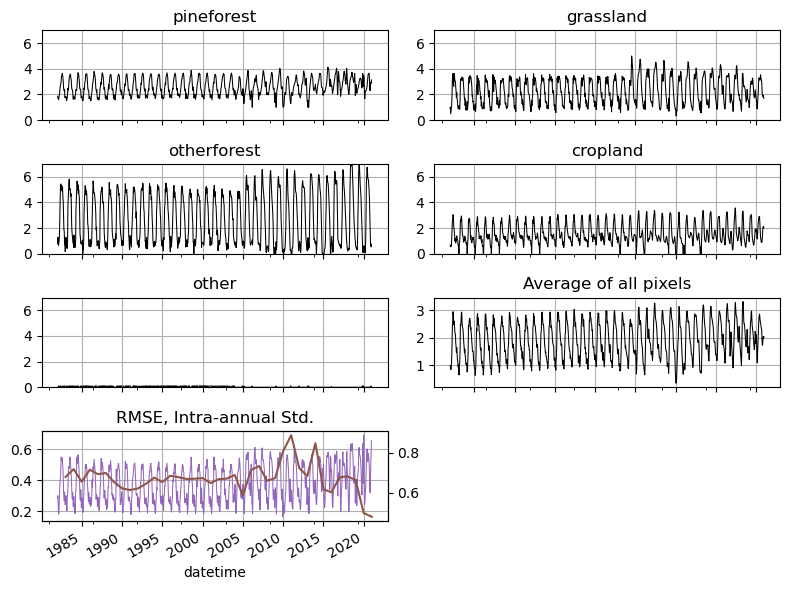

In [138]:
fig, ax = plt.subplots(4,2, figsize=(8,6), sharex=True)
ax = ax.ravel()
for i, lut in enumerate(ccodes.keys()):
    plt.sca(ax[i])
    bblai[[lut]].plot(ax=ax[i], title=lut, legend=False, color="black", lw=0.75)
    plt.ylim(0,7)
    plt.yticks(np.arange(0,8,2))
    plt.grid()

plt.sca(ax[-3])
plt.plot(df.index, df.mean(axis=1), color="black", lw=0.75)
plt.title("Average of all pixels")
plt.grid()

plt.sca(ax[-2])
errors[["rmse"]].plot(ax=ax[-2], title="RMSE, Intra-annual Std.", legend=False, color="tab:purple", lw=0.75)
plt.grid()
ax2=plt.twinx()
tmp = df.mean(axis=1).resample("YE").std()
plt.plot(tmp.index, tmp, color="tab:brown")

ax[-1].axis("off")

plt.tight_layout()


In [110]:
bblaibiweek = bblai.groupby([bblai.index.month, bblai.index.day]).mean()

newindex = []
for i in range(1,13):
    for j in [1,15]:
        newindex.append(dt.datetime(2024, i, j))
bblaibiweek.index = newindex

Text(0, 0.5, 'LAI, m²/m²')

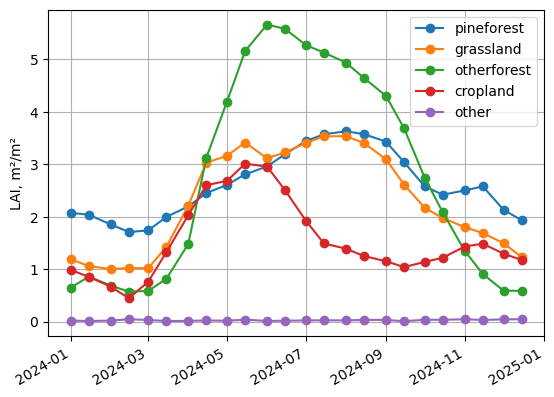

In [111]:
ax = bblaibiweek.plot(marker="o")
plt.sca(ax)
plt.grid()
plt.ylabel("LAI, m²/m²")

In [143]:
def get_linear_trend(df, var, start, end, verbose=True):
    tmptrend = df.loc[start:end]
    tmptrend.loc[tmptrend.index,["delta"]] = [(item - tmptrend.index[0]).total_seconds() for item in tmptrend.index]
    slope, intercept, r, p, se = scipy.stats.linregress(tmptrend.delta.to_numpy(), tmptrend[var].to_numpy())
    ypred = intercept + slope*tmptrend.delta
    pstr = get_sign_level(p)
    slope *= 365.25*86400*10
    se *= 365.25*86400*10
    if verbose:
        print("slope=%.2f dec⁻¹ +/- %.2f dec⁻¹, %s (p=%.3f)" % (slope, se, pstr, p))
    return slope, intercept, r, p, se, ypred, pstr
for lut in ccodes.keys():
    print(lut)
    _ = get_linear_trend(bblai.astype(float), lut, "1982-01-01", "2020-12-31")
print("all")
tmp = df.mean(axis=1)
tmp
_ = get_linear_trend(pd.DataFrame(df.mean(axis=1)), 0, "1982-01-01", "2020-12-31")

pineforest
slope=0.10 dec⁻¹ +/- 0.02 dec⁻¹, *** (p=0.000)
grassland
slope=0.09 dec⁻¹ +/- 0.03 dec⁻¹, *** (p=0.002)
otherforest
slope=0.06 dec⁻¹ +/- 0.06 dec⁻¹,     (p=0.323)
cropland
slope=0.06 dec⁻¹ +/- 0.02 dec⁻¹, **  (p=0.010)
other
slope=-0.01 dec⁻¹ +/- 0.00 dec⁻¹, *** (p=0.000)
all
slope=0.09 dec⁻¹ +/- 0.02 dec⁻¹, *** (p=0.000)


# Manually selected pixels from Cao

In [11]:
trgs = {}
masks = {}

In [13]:
trgs["pineforest"] = gpd.read_file("/media/x/cosmicsense/data/brandenburg/vast-landuse/cao-pine-pixels.geojson")
trgs["broadleave"] = gpd.read_file("/media/x/cosmicsense/data/brandenburg/vast-landuse/cao-broadleave-pixels.geojson")

In [14]:
ro = rio.open(files[500])

In [17]:
trgs["pineforest"] = trgs["pineforest"].dissolve()
mask, transform = riom.mask(ro, [geom for geom in trgs["pineforest"].geometry])#, all_touched=True)
masks["pineforest"] = mask.astype("bool")[0]

/home/maik/miniforge3/envs/cs3/lib/python3.11/site-packages/rasterio/mask.py:191: RuntimeWarning: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
  out_image = dataset.read(


In [18]:
trgs["broadleave"] = trgs["broadleave"].dissolve()
mask, transform = riom.mask(ro, [geom for geom in trgs["broadleave"].geometry])#, all_touched=True)
masks["broadleave"] = mask.astype("bool")[0]

In [19]:
masks["broadleave"].sum()

5

(51.5, 53.5)

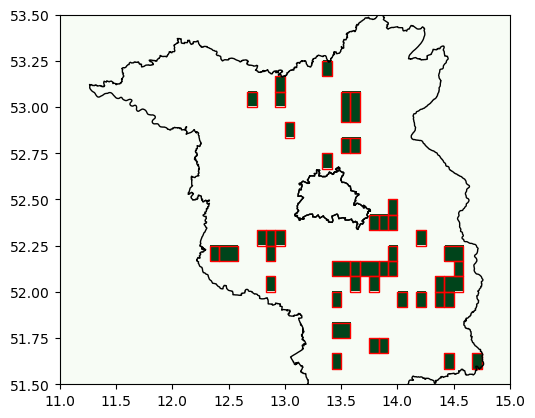

In [20]:
fig, ax = plt.subplots(1,1)
plt.imshow(masks["pineforest"], extent=(-180, 180, -90, 90), cmap=plt.cm.Greens)
trgs["pineforest"].plot(ax=ax, facecolor="None", edgecolor="red")
bb.plot(ax=ax, facecolor="None", edgecolor="black")
plt.xlim(11,15)
plt.ylim(51.5,53.5)

In [21]:
#trg = gpd.read_file("/media/x/cosmicsense/git/brandenburg/de/standorte/bb.geojson")
# grasslands
trgs["grassland"] = gpd.read_file("/media/x/cosmicsense/data/brandenburg/vast-landuse/vast_grasslands.shp")
#trgs["grassland"].plot()
#ro.crs = bb.crs
mask, transform = riom.mask(ro, [geom for geom in trgs["grassland"].geometry])#, all_touched=True)
masks["grassland"] = mask.astype("bool")[0]

(51.5, 53.5)

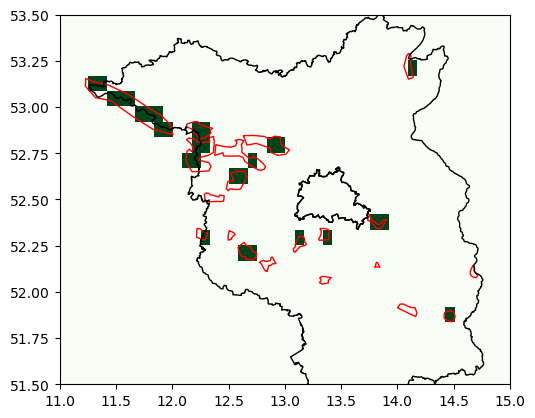

In [22]:
fig, ax = plt.subplots(1,1)
plt.imshow(masks["grassland"], extent=(-180, 180, -90, 90), cmap=plt.cm.Greens)
trgs["grassland"].plot(ax=ax, facecolor="None", edgecolor="red")
bb.plot(ax=ax, facecolor="None", edgecolor="black")
plt.xlim(11,15)
plt.ylim(51.5,53.5)

In [23]:
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message="TIFFReadDirectory:Sum of Photometric.*"
)

In [24]:
read_anew = True
results = {}

if read_anew:
    dtimes = []
    #alldata = np.zeros( (len(files), ro.shape[0], ro.shape[1]) )
    
    for file in files:
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        dtimes.append(dtime)
    
    df = pd.DataFrame(index=dtimes, columns=list(trgs.keys()))
    dfmax = pd.DataFrame(index=dtimes, columns=list(trgs.keys()))
    dfmin = pd.DataFrame(index=dtimes, columns=list(trgs.keys()))
    df = df.sort_index()
    dfmax = dfmax.sort_index()
    dfmin = dfmin.sort_index()   

    warnings.filterwarnings("ignore", category=UserWarning)
    for file in files:
        print(".", end="")
        fname = os.path.basename(file)
        dtime = dt.datetime.strptime(fname, "GIMMS_LAI4g_V1.2_%Y%m%d.tif")
        data = read_lai_file(file)
        for key in list(trgs.keys()):
            tmp = data[masks[key]].ravel()
            tmp = tmp[~np.isnan(tmp)]
            avg = np.mean(tmp)
            df.loc[[dtime],[key]] = [avg]
            mini, maxi = np.quantile(tmp, [0.25, 0.75])
            dfmax.loc[[dtime],[key]] = [maxi]
            dfmin.loc[[dtime],[key]] = [mini]
        # tmp = rio.open(file)
        # data = tmp.read(1)
        # data = data.astype("f4")
        # data[data==65535.] = np.nan
        # data *= 0.001
        #avgs.append(np.nanmean(data[latmini:latmaxi, lonmini:lonmaxi]))
    print("")
    warnings.filterwarnings("default", category=UserWarning)
    #df.to_csv(os.path.join(data_dir, "series4trends/lai.csv"), index=True, index_label="datetime")
else:
    pass
    #df = pd.read_csv(os.path.join(data_dir, "series4trends/lai.csv"), parse_dates=True, index_col="datetime")

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................


Text(0.5, 1.0, 'Grassland')

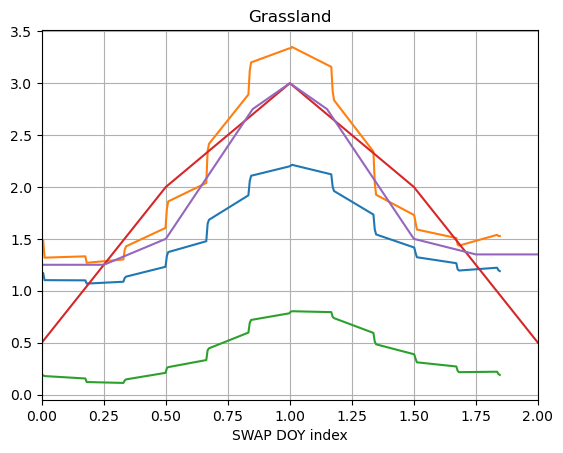

In [153]:
fig, ax = plt.subplots(1,1)
tmp = df.groupby(df.index.dayofyear).mean()
plt.plot(2*tmp.index/365, tmp)
tmp = dfmax.groupby(dfmax.index.dayofyear).mean()
plt.plot(2*tmp.index/365, tmp)
tmp = dfmin.groupby(dfmax.index.dayofyear).mean()
plt.plot(2*tmp.index/365, tmp)
# Previous seasonal LAI for grass
plt.plot([0, 0.5, 1, 1.5, 2], [0.5, 2., 3., 2., 0.5])
plt.plot([0, 0.25, 0.5, 0.85, 1., 1.15, 1.5, 1.75, 2], [1.25, 1.25, 1.5, 2.75, 3., 2.75, 1.5, 1.35, 1.35])
plt.xlabel("SWAP DOY index")
plt.xlim(0,2)
plt.grid()
plt.title("Grassland")

Text(0.5, 1.0, 'Kiefernforste')

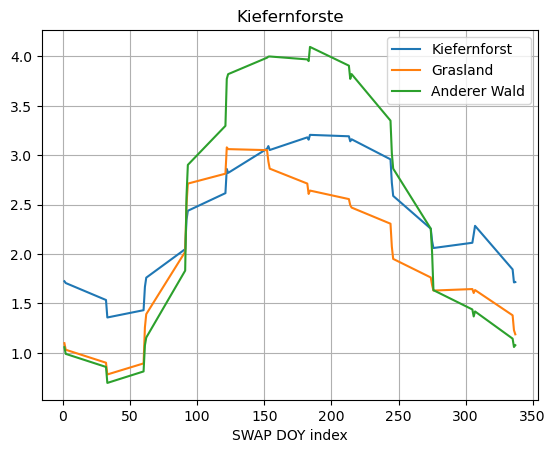

In [76]:
fig, ax = plt.subplots(1,1)
tmp = df.groupby(df.index.dayofyear).mean()
plt.plot(tmp.index, tmp["pineforest"], label="Kiefernforst")
plt.plot(tmp.index, tmp["grassland"], label="Grasland")
plt.plot(tmp.index, tmp["broadleave"], label="Anderer Wald")
# tmp = dfmax.groupby(dfmax.index.dayofyear).mean()
# plt.plot(2*tmp.index/365, tmp, label="75. Perzentil")
# tmp = dfmin.groupby(dfmax.index.dayofyear).mean()
# plt.plot(2*tmp.index/365, tmp, label="25. Perzentil")
# Previous seasonal LAI for grass
#plt.plot([0, 0.5, 1, 1.5, 2], [0.5, 2., 3., 2., 0.5])
#plt.plot([0, 0.25, 0.5, 0.85, 1., 1.15, 1.5, 1.75, 2], [1.25, 1.25, 1.5, 2.75, 3., 2.75, 1.5, 1.35, 1.35])
plt.xlabel("SWAP DOY index")
plt.legend()
#plt.xlim(0,2)
plt.grid()
plt.title("Kiefernforste")

In [42]:
for landuse in df.columns:
    print(landuse)
    slope, intercept, r, p, se, ypred, pstr = get_linear_trend(df, landuse, "1981-01-01", "2020-12-31")

pineforest
slope=0.114*** +/- 0.019, p=0.000
broadleave
slope=0.173*** +/- 0.038, p=0.000
grassland
slope=0.105*** +/- 0.022, p=0.000


In [41]:
def get_linear_trend(df, var, start, end, verbose=True):
    tmptrend = df.loc[start:end]
    tmptrend.loc[tmptrend.index,["delta"]] = [(item - tmptrend.index[0]).total_seconds() for item in tmptrend.index]
    slope, intercept, r, p, se = scipy.stats.linregress(
        tmptrend.delta.to_numpy(), tmptrend[var].astype("float").to_numpy())
    ypred = intercept + slope*tmptrend.delta
    pstr = get_sign_level(p)
    slope *= 365.25*86400*10
    se *= 365.25*86400*10
    if verbose:
        print("slope=%.3f%s +/- %.3f, p=%.3f" % (slope, pstr, se, p))
    return slope, intercept, r, p, se, ypred, pstr

In [36]:
tmptrend = df.loc["1981-01-01":"2020-12-31"]
tmptrend.loc[tmptrend.index,["delta"]] = [(item - tmptrend.index[0]).total_seconds() for item in tmptrend.index]
slope, intercept, r, p, se = scipy.stats.linregress(tmptrend.delta.to_numpy(), tmptrend["pineforest"].astype("float").to_numpy())